# Fast split-half reliability curves with MAD error bars

This Colab estimates split-half reliability for ratings, object 2AFC, drawing 2AFC, and n-back memorability.

Main choices:
- removes invalid `image_idx > 100`
- uses `N_ITER = 200`
- computes full-data split-half reliability
- computes reliability as a function of sampled repetitions per image, from 2–16
- summarizes resampling variability using **MAD** rather than percentile CI
- plots using a compact `journal_figure()` style helper
- uses Spearman-Brown correction by default
- adds a 16-repetition image-label shuffle null showing reliability collapses toward zero


In [ ]:
# Setup
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

EXPECTED_FILES = [
    "all_data_ratings.csv",
    "all_data_obj_2afc.csv",
    "all_data_draw_2afc.csv",
    "all_data_n_back.csv",
]

missing = [f for f in EXPECTED_FILES if not Path(f).exists()]
if missing:
    try:
        from google.colab import files
        print("Please upload:", missing)
        uploaded = files.upload()
    except Exception:
        print("Missing files:", missing)
        print("Put the CSV files in the notebook working directory and rerun this cell.")
else:
    print("All expected files found.")


All expected files found.


In [ ]:
# Settings

VALID_IMAGE_MIN = 0
VALID_IMAGE_MAX = 100   # image_idx > 100 are invalid

# Use None for all valid images. Use list(range(60)) to reproduce the original 0:59 analyses.
FORCE_IMAGE_SET = None

REPS_TO_TEST = list(range(2, 17))

# Requested setting.
N_ITER = 200

RANDOM_SEED = 1
APPLY_SPEARMAN_BROWN = True

# Pearson is fast and matches your original 2AFC/rating code.
# Use "spearman" if you want a rank-based reliability estimate.
CORRELATION_METHOD = "pearson"  # "pearson" or "spearman"

# For n-back, memorability is typically defined on repeated images.
NBACK_REQUIRE_REPEAT_LAG_NONZERO = True

# Keep this False for speed. Turn True only if you need all individual resampling draws saved.
SAVE_RAW_DRAWS = False


In [ ]:
def journal_figure(figsize=(3.25, 2.4), fontsize=7, dpi=300):
    """Compact journal-style Matplotlib defaults."""
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
        "savefig.dpi": dpi,
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize - 1,
        "ytick.labelsize": fontsize - 1,
        "legend.fontsize": fontsize - 1,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "lines.linewidth": 1.2,
        "lines.markersize": 3.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })


def despine(ax=None):
    if ax is None:
        ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")
    return ax

journal_figure()


In [ ]:
def to_bool_series(s):
    """Robustly convert bool/string/numeric columns to True/False."""
    if pd.api.types.is_bool_dtype(s):
        return s.fillna(False).astype(bool)
    return s.astype(str).str.strip().str.lower().isin(["true", "1", "yes", "y"])


def spearman_brown(r):
    r = np.asarray(r, dtype=float)
    out = (2 * r) / (1 + r)
    out[~np.isfinite(out)] = np.nan
    out[np.isclose(1 + r, 0)] = np.nan
    return out


def mad(arr, scale=1.0):
    """Median absolute deviation around the median.

    scale=1.0 gives raw MAD. Use scale=1.4826 if you want normal-consistent MAD.
    """
    arr = np.asarray(arr, dtype=float)
    med = np.nanmedian(arr)
    return scale * np.nanmedian(np.abs(arr - med))


def corr_rows(a, b, method="pearson"):
    """
    Fast row-wise correlation between A and B.
    A and B are shaped [n_iter, n_images].
    Returns one correlation per row.
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if method.lower() == "spearman":
        # Rank each row. This is slower than Pearson, but still much faster than scipy in a loop.
        a = pd.DataFrame(a).rank(axis=1).to_numpy()
        b = pd.DataFrame(b).rank(axis=1).to_numpy()

    a = a - np.nanmean(a, axis=1, keepdims=True)
    b = b - np.nanmean(b, axis=1, keepdims=True)

    num = np.nansum(a * b, axis=1)
    den = np.sqrt(np.nansum(a * a, axis=1) * np.nansum(b * b, axis=1))

    with np.errstate(divide="ignore", invalid="ignore"):
        r = num / den
    r[~np.isfinite(r)] = np.nan
    return r


In [ ]:
def prepare_dataset(dataset_name, filename):
    """Load one dataset and return columns: dataset, image_idx, score."""
    d = pd.read_csv(filename)

    if "image_idx" not in d.columns:
        raise ValueError(f"{filename} has no image_idx column.")

    d = d[d["image_idx"].notna()].copy()
    d["image_idx"] = d["image_idx"].astype(int)
    d = d[(d["image_idx"] >= VALID_IMAGE_MIN) & (d["image_idx"] <= VALID_IMAGE_MAX)].copy()

    if FORCE_IMAGE_SET is not None:
        d = d[d["image_idx"].isin(FORCE_IMAGE_SET)].copy()

    if dataset_name in ["object_2afc", "drawing_2afc"]:
        if "correct" not in d.columns:
            raise ValueError(f"{filename} has no correct column.")
        d["score"] = to_bool_series(d["correct"]).astype(float)
        score_name = "accuracy"

    elif dataset_name == "ratings":
        if "rating" not in d.columns:
            raise ValueError(f"{filename} has no rating column.")
        d["score"] = pd.to_numeric(d["rating"], errors="coerce")
        score_name = "rating"

    elif dataset_name == "n_back_memorability":
        if "correct_at_second_occurrence" not in d.columns:
            raise ValueError(f"{filename} has no correct_at_second_occurrence column.")

        d = d[d["correct_at_second_occurrence"].notna()].copy()

        if NBACK_REQUIRE_REPEAT_LAG_NONZERO and "repeat_lag" in d.columns:
            d = d[d["repeat_lag"] != 0].copy()

        d["score"] = to_bool_series(d["correct_at_second_occurrence"]).astype(float)
        score_name = "second_occurrence_accuracy"

    else:
        raise ValueError(f"Unknown dataset_name: {dataset_name}")

    out = d[["image_idx", "score"]].dropna().copy()
    out["dataset"] = dataset_name
    return out[["dataset", "image_idx", "score"]], score_name


DATASETS = {
    "ratings": "all_data_ratings.csv",
    "object_2afc": "all_data_obj_2afc.csv",
    "drawing_2afc": "all_data_draw_2afc.csv",
    "n_back_memorability": "all_data_n_back.csv",
}

prepared = {}
score_names = {}

for name, filename in DATASETS.items():
    df, score_name = prepare_dataset(name, filename)
    prepared[name] = df
    score_names[name] = score_name

    counts = df.groupby("image_idx").size()
    print()
    print(name)
    print(f"  score: {score_name}")
    print(f"  rows after filtering: {len(df)}")
    print(f"  images after filtering: {df.image_idx.nunique()}")
    print(f"  reps/image: min={counts.min()}, median={counts.median()}, max={counts.max()}")
    print(f"  image_idx range: {df.image_idx.min()} to {df.image_idx.max()}")



ratings
  score: rating
  rows after filtering: 996
  images after filtering: 60
  reps/image: min=15, median=17.0, max=18
  image_idx range: 0 to 59

object_2afc
  score: accuracy
  rows after filtering: 1014
  images after filtering: 60
  reps/image: min=15, median=17.0, max=17
  image_idx range: 0 to 59

drawing_2afc
  score: accuracy
  rows after filtering: 1015
  images after filtering: 60
  reps/image: min=16, median=17.0, max=18
  image_idx range: 0 to 59

n_back_memorability
  score: second_occurrence_accuracy
  rows after filtering: 306
  images after filtering: 18
  reps/image: min=17, median=17.0, max=17
  image_idx range: 0 to 52


In [ ]:
def make_groups(df):
    """Return dict image_idx -> score vector."""
    return {
        int(img): g["score"].to_numpy(dtype=float)
        for img, g in df.groupby("image_idx", sort=True)
        if len(g) > 0
    }


def fast_split_half_fixed_k(groups, k, n_iter=200, seed=1, method="pearson", apply_sb=True):
    """
    Fast split-half reliability for exactly k sampled repetitions per image.

    For each image:
    - sample k trials without replacement on each iteration
    - first floor(k/2) go to half 1
    - remaining trials go to half 2
    """
    rng = np.random.default_rng(seed)

    eligible_items = [(img, v) for img, v in groups.items() if len(v) >= k]
    n_images = len(eligible_items)

    if n_images < 3:
        return np.full(n_iter, np.nan), n_images

    split = k // 2
    half1 = np.empty((n_iter, n_images), dtype=float)
    half2 = np.empty((n_iter, n_images), dtype=float)

    for col, (img, values) in enumerate(eligible_items):
        n = len(values)

        # Random without-replacement samples by sorting random keys.
        idx = np.argpartition(rng.random((n_iter, n)), kth=k-1, axis=1)[:, :k]

        # Randomize order within the selected k samples before splitting.
        order = np.argsort(rng.random((n_iter, k)), axis=1)
        idx = np.take_along_axis(idx, order, axis=1)

        sampled = values[idx]
        half1[:, col] = sampled[:, :split].mean(axis=1)
        half2[:, col] = sampled[:, split:].mean(axis=1)

    r = corr_rows(half1, half2, method=method)

    if apply_sb:
        r = spearman_brown(r)

    return r, n_images


def fast_split_half_all_available(groups, n_iter=200, seed=1, method="pearson", apply_sb=True):
    """
    Split-half reliability using all available repetitions per image.
    Images can have different trial counts; iterations are vectorized within each image.
    """
    rng = np.random.default_rng(seed)

    eligible_items = [(img, v) for img, v in groups.items() if len(v) >= 2]
    n_images = len(eligible_items)

    if n_images < 3:
        return np.full(n_iter, np.nan), n_images

    half1 = np.empty((n_iter, n_images), dtype=float)
    half2 = np.empty((n_iter, n_images), dtype=float)

    for col, (img, values) in enumerate(eligible_items):
        n = len(values)
        split = n // 2

        idx = np.argsort(rng.random((n_iter, n)), axis=1)
        sampled = values[idx]
        half1[:, col] = sampled[:, :split].mean(axis=1)
        half2[:, col] = sampled[:, split:].mean(axis=1)

    r = corr_rows(half1, half2, method=method)

    if apply_sb:
        r = spearman_brown(r)

    return r, n_images


def summarize_draws(arr):
    arr = np.asarray(arr, dtype=float)
    med = np.nanmedian(arr)
    m = mad(arr, scale=1.0)
    return {
        "reliability_mean": np.nanmean(arr),
        "reliability_median": med,
        "reliability_mad": m,
        "error_low_median_minus_mad": med - m,
        "error_high_median_plus_mad": med + m,
        "reliability_sd": np.nanstd(arr),
        "n_valid_iterations": np.isfinite(arr).sum(),
    }


In [ ]:
# Run fast reliability analyses

summary_rows = []
curve_rows = []
raw_rows = []

for dataset_name, df in prepared.items():
    groups = make_groups(df)

    full_draws, full_n_images = fast_split_half_all_available(
        groups,
        n_iter=N_ITER,
        seed=RANDOM_SEED,
        method=CORRELATION_METHOD,
        apply_sb=APPLY_SPEARMAN_BROWN,
    )

    full_summary = summarize_draws(full_draws)

    summary_rows.append({
        "dataset": dataset_name,
        "score": score_names[dataset_name],
        "n_rows": len(df),
        "n_images": df.image_idx.nunique(),
        "n_images_full_split_half": full_n_images,
        "full_split_half_mean": full_summary["reliability_mean"],
        "full_split_half_median": full_summary["reliability_median"],
        "full_split_half_mad": full_summary["reliability_mad"],
        "full_split_half_median_minus_mad": full_summary["error_low_median_minus_mad"],
        "full_split_half_median_plus_mad": full_summary["error_high_median_plus_mad"],
    })

    for k in REPS_TO_TEST:
        draws, n_images = fast_split_half_fixed_k(
            groups,
            k=k,
            n_iter=N_ITER,
            seed=RANDOM_SEED + 1000 * k,
            method=CORRELATION_METHOD,
            apply_sb=APPLY_SPEARMAN_BROWN,
        )

        row = {
            "dataset": dataset_name,
            "score": score_names[dataset_name],
            "repetitions_per_image": k,
            "n_images": n_images,
        }
        row.update(summarize_draws(draws))
        curve_rows.append(row)

        if SAVE_RAW_DRAWS:
            raw_rows.extend([
                {
                    "dataset": dataset_name,
                    "repetitions_per_image": k,
                    "iteration": i,
                    "reliability": val,
                    "n_images": n_images,
                }
                for i, val in enumerate(draws)
            ])

summary = pd.DataFrame(summary_rows)
curves = pd.DataFrame(curve_rows)
raw_draws = pd.DataFrame(raw_rows)

display(summary)
display(curves.head(20))


,dataset,score,n_rows,n_images,n_images_full_split_half,full_split_half_mean,full_split_half_median,full_split_half_mad,full_split_half_median_minus_mad,full_split_half_median_plus_mad
0,ratings,rating,996,60,60,0.390363,0.396563,0.078421,0.318142,0.474983
1,object_2afc,accuracy,1014,60,60,0.745058,0.751753,0.044071,0.707682,0.795824
2,drawing_2afc,accuracy,1015,60,60,0.757128,0.765928,0.034342,0.731586,0.800269
3,n_back_memorability,second_occurrence_accuracy,306,18,18,0.704385,0.709055,0.068080,0.640975,0.777135


,dataset,score,repetitions_per_image,n_images,reliability_mean,reliability_median,reliability_mad,error_low_median_minus_mad,error_high_median_plus_mad,reliability_sd,n_valid_iterations
0,ratings,rating,2,60,0.043512,0.085439,0.190423,-0.104984,0.275862,0.266280,200
1,ratings,rating,3,60,0.087147,0.103433,0.147464,-0.044031,0.250897,0.235775,200
2,ratings,rating,4,60,0.095009,0.146958,0.153671,-0.006713,0.300629,0.248602,200
3,ratings,rating,5,60,0.128155,0.166002,0.141616,0.024386,0.307618,0.234951,200
4,ratings,rating,6,60,0.168456,0.197907,0.125632,0.072275,0.323539,0.212443,200
5,ratings,rating,7,60,0.203773,0.211740,0.116223,0.095517,0.327964,0.166807,200
6,ratings,rating,8,60,0.198597,0.231342,0.118973,0.112368,0.350315,0.192375,200
7,ratings,rating,9,60,0.243873,0.262187,0.118344,0.143843,0.380531,0.171350,200
8,ratings,rating,10,60,0.251773,0.270699,0.106506,0.164193,0.377204,0.163275,200
9,ratings,rating,11,60,0.288018,0.317598,0.098851,0.218746,0.416449,0.167859,200


In [ ]:
# Save outputs

summary.to_csv("split_half_reliability_summary_N200_MAD.csv", index=False)
curves.to_csv("split_half_reliability_by_repetitions_N200_MAD.csv", index=False)

print("Saved:")
print("  split_half_reliability_summary_N200_MAD.csv")
print("  split_half_reliability_by_repetitions_N200_MAD.csv")

if SAVE_RAW_DRAWS:
    raw_draws.to_csv("split_half_reliability_raw_draws_N200_MAD.csv", index=False)
    print("  split_half_reliability_raw_draws_N200_MAD.csv")


Saved:
  split_half_reliability_summary_N200_MAD.csv
  split_half_reliability_by_repetitions_N200_MAD.csv


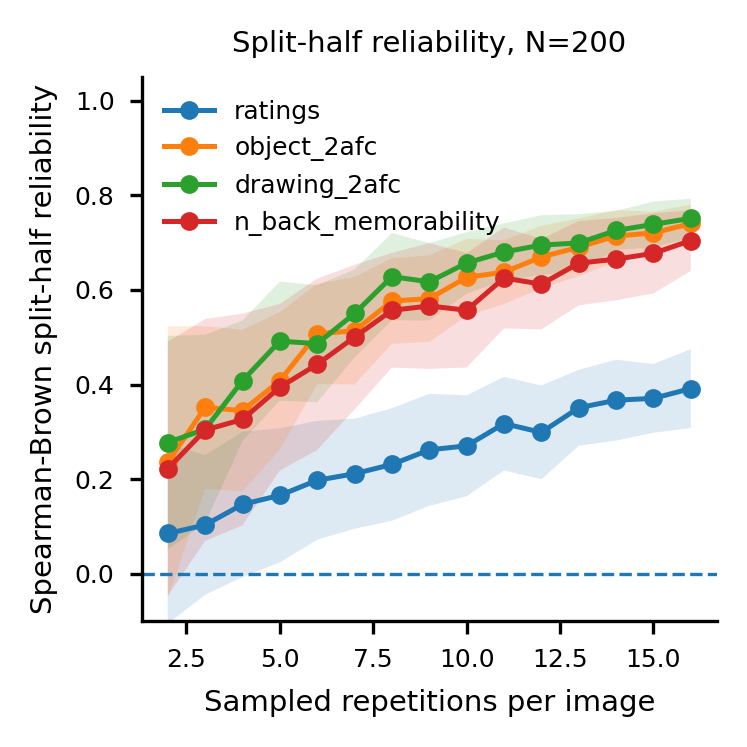

In [ ]:
# Journal-style plot: reliability median ± MAD as a function of repetitions per image

journal_figure(figsize=(2.5, 2.5), fontsize=7, dpi=300)
fig, ax = plt.subplots()

for dataset_name in curves["dataset"].unique():
    c = curves[curves["dataset"] == dataset_name].copy()
    x = c["repetitions_per_image"].to_numpy()
    y = c["reliability_median"].to_numpy()
    err = c["reliability_mad"].to_numpy()

    ax.plot(x, y, marker="o", label=dataset_name)
    ax.fill_between(x, y - err, y + err, alpha=0.15, linewidth=0)

ax.axhline(0, linestyle="--", linewidth=0.8)
ax.set_ylim(-0.1, 1.05)
ax.set_xlabel("Sampled repetitions per image")
ylabel = "Spearman-Brown split-half reliability" if APPLY_SPEARMAN_BROWN else "Raw split-half correlation"
ax.set_ylabel(ylabel)
ax.set_title(f"Split-half reliability, N={N_ITER}")
ax.legend(frameon=False)
despine(ax)
fig.tight_layout()
fig.savefig("split_half_reliability_by_repetitions_N200_MAD_journal.png", bbox_inches="tight")
fig.savefig("split_half_reliability_by_repetitions_N200_MAD_journal.pdf", bbox_inches="tight")
plt.show()


In [ ]:
# Optional image-level scores

image_level_scores = []

for name, df in prepared.items():
    tmp = (
        df.groupby("image_idx", as_index=False)
        .agg(
            score_mean=("score", "mean"),
            score_sd=("score", "std"),
            n=("score", "size"),
        )
    )
    tmp["dataset"] = name
    tmp["score"] = score_names[name]
    image_level_scores.append(tmp)

image_level_scores = pd.concat(image_level_scores, ignore_index=True)
image_level_scores.to_csv("image_level_scores_N200_MAD.csv", index=False)

display(image_level_scores.head())
print("Saved: image_level_scores_N200_MAD.csv")


,image_idx,score_mean,score_sd,n,dataset,score
0,0,2.277778,1.127494,18,ratings,rating
1,1,3.000000,1.500000,17,ratings,rating
2,2,3.277778,1.178511,18,ratings,rating
3,3,2.750000,1.483240,16,ratings,rating
4,4,2.411765,1.175735,17,ratings,rating


Saved: image_level_scores_N200_MAD.csv


## Image-label shuffle null at 16 repetitions per image

This block implements the MATLAB-style control where `image_idx` is randomly permuted across rows before computing split-half reliability. The score values stay the same, but the image labels are broken. At 16 sampled repetitions per image, the reliability should be near zero on average if the split-half signal depends on true image identity.


In [ ]:
# Image-label shuffle null at 16 repetitions per image

NULL_REPS_PER_IMAGE = 16

# Fast default: one split-half estimate per shuffled image-label permutation.
# To mimic the nested MATLAB structure more closely, increase this to 50.
N_NULL_SPLITS_PER_SHUFFLE = 1
N_NULL_IMAGE_SHUFFLES = N_ITER


def shuffled_image_idx_split_half_null(
    df,
    k=16,
    n_label_shuffles=200,
    n_splits_per_shuffle=1,
    seed=1,
    method="pearson",
    apply_sb=True,
):
    """
    MATLAB-style image_idx shuffle null.

    For each null iteration:
    - randomly permute image_idx across rows
    - regroup trials by the shuffled image_idx
    - compute split-half reliability using exactly k repetitions per image

    Returns all split-half draws as a flat vector.
    """
    rng = np.random.default_rng(seed)
    image_idx = df["image_idx"].to_numpy(copy=True)
    all_draws = []
    n_images_used = []

    for s in range(n_label_shuffles):
        tmp = df.copy()
        tmp["image_idx"] = rng.permutation(image_idx)
        groups = make_groups(tmp)

        draws, n_images = fast_split_half_fixed_k(
            groups,
            k=k,
            n_iter=n_splits_per_shuffle,
            seed=seed + 100_000 * s,
            method=method,
            apply_sb=apply_sb,
        )
        all_draws.append(draws)
        n_images_used.append(n_images)

    return np.concatenate(all_draws), np.asarray(n_images_used)


shuffle_rows = []
shuffle_draw_rows = []

for dataset_name, df in prepared.items():
    null_draws, n_images_used = shuffled_image_idx_split_half_null(
        df,
        k=NULL_REPS_PER_IMAGE,
        n_label_shuffles=N_NULL_IMAGE_SHUFFLES,
        n_splits_per_shuffle=N_NULL_SPLITS_PER_SHUFFLE,
        seed=RANDOM_SEED + 99_999 + 10_000 * list(prepared.keys()).index(dataset_name),
        method=CORRELATION_METHOD,
        apply_sb=APPLY_SPEARMAN_BROWN,
    )

    null_summary = summarize_draws(null_draws)

    actual_row = curves[
        (curves["dataset"] == dataset_name)
        & (curves["repetitions_per_image"] == NULL_REPS_PER_IMAGE)
    ].iloc[0]

    shuffle_rows.append({
        "dataset": dataset_name,
        "repetitions_per_image": NULL_REPS_PER_IMAGE,
        "actual_median": actual_row["reliability_median"],
        "actual_mad": actual_row["reliability_mad"],
        "shuffled_image_idx_mean": null_summary["reliability_mean"],
        "shuffled_image_idx_median": null_summary["reliability_median"],
        "shuffled_image_idx_mad": null_summary["reliability_mad"],
        "shuffled_image_idx_median_minus_mad": null_summary["error_low_median_minus_mad"],
        "shuffled_image_idx_median_plus_mad": null_summary["error_high_median_plus_mad"],
        "n_valid_null_draws": null_summary["n_valid_iterations"],
        "mean_n_images_used_after_shuffle": np.nanmean(n_images_used),
        "n_label_shuffles": N_NULL_IMAGE_SHUFFLES,
        "n_splits_per_shuffle": N_NULL_SPLITS_PER_SHUFFLE,
    })

    if SAVE_RAW_DRAWS:
        for draw_i, val in enumerate(null_draws):
            shuffle_draw_rows.append({
                "dataset": dataset_name,
                "draw": draw_i,
                "repetitions_per_image": NULL_REPS_PER_IMAGE,
                "reliability": val,
            })

shuffle_null_summary = pd.DataFrame(shuffle_rows)
shuffle_null_summary.to_csv("split_half_image_idx_shuffle_null_16reps_N200_MAD.csv", index=False)

print("Saved: split_half_image_idx_shuffle_null_16reps_N200_MAD.csv")
display(shuffle_null_summary)

if SAVE_RAW_DRAWS:
    shuffle_null_raw_draws = pd.DataFrame(shuffle_draw_rows)
    shuffle_null_raw_draws.to_csv("split_half_image_idx_shuffle_null_raw_draws_16reps_N200_MAD.csv", index=False)
    print("Saved: split_half_image_idx_shuffle_null_raw_draws_16reps_N200_MAD.csv")


Saved: split_half_image_idx_shuffle_null_16reps_N200_MAD.csv


,dataset,repetitions_per_image,actual_median,actual_mad,shuffled_image_idx_mean,shuffled_image_idx_median,shuffled_image_idx_mad,shuffled_image_idx_median_minus_mad,shuffled_image_idx_median_plus_mad,n_valid_null_draws,mean_n_images_used_after_shuffle,n_label_shuffles,n_splits_per_shuffle
0,ratings,16,0.391685,0.083365,0.006055,0.046549,0.156650,-0.110101,0.203199,200,59.0,200,1
1,object_2afc,16,0.740454,0.040028,-0.036622,-0.035629,0.191641,-0.227270,0.156011,200,59.0,200,1
2,drawing_2afc,16,0.751482,0.041334,-0.026235,0.035271,0.178613,-0.143342,0.213883,200,60.0,200,1
3,n_back_memorability,16,0.704433,0.064080,-0.121125,0.066350,0.293385,-0.227035,0.359734,200,18.0,200,1


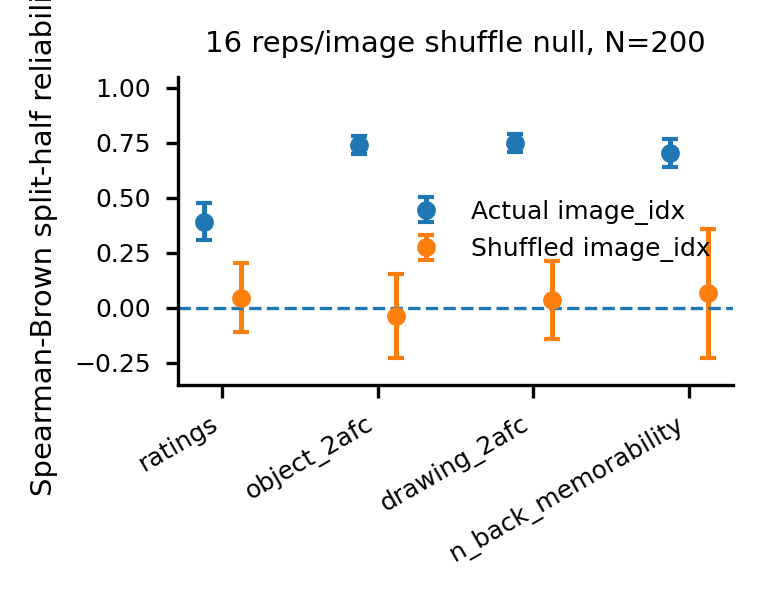

In [ ]:
# Plot actual vs image_idx-shuffled reliability at 16 repetitions per image

journal_figure(figsize=(2.5, 2), fontsize=7, dpi=300)
fig, ax = plt.subplots()

x = np.arange(len(shuffle_null_summary))
labels = shuffle_null_summary["dataset"].to_list()

ax.errorbar(
    x - 0.12,
    shuffle_null_summary["actual_median"],
    yerr=shuffle_null_summary["actual_mad"],
    fmt="o",
    capsize=2,
    label="Actual image_idx",
)
ax.errorbar(
    x + 0.12,
    shuffle_null_summary["shuffled_image_idx_median"],
    yerr=shuffle_null_summary["shuffled_image_idx_mad"],
    fmt="o",
    capsize=2,
    label="Shuffled image_idx",
)

ax.axhline(0, linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel(ylabel)
ax.set_title(f"16 reps/image shuffle null, N={N_ITER}")
ax.set_ylim(-0.35, 1.05)
ax.legend(frameon=False)
despine(ax)
fig.tight_layout()
fig.savefig("split_half_image_idx_shuffle_null_16reps_N200_MAD_journal.png", bbox_inches="tight")
fig.savefig("split_half_image_idx_shuffle_null_16reps_N200_MAD_journal.pdf", bbox_inches="tight")
plt.show()


## Notes

The plotted line is the **median** reliability across `N_ITER = 200` random split-half draws. The shaded region is **median ± MAD** across draws, not a 95% confidence interval.

For final paper-style export, use the saved PDF:

```text
split_half_reliability_by_repetitions_N200_MAD_journal.pdf
```
